
# Simple Annotated Simulation for Testing MMD Batch Correction

This notebook runs **one reliable annotated simulation** to test whether the MMD batch-correction term in your SpatialGLUE-style model is helping.

It does exactly four things:

1. Generate **one annotated synthetic spatial multi-omics dataset**
2. Train the model **without** batch correction
3. Train the model **with MMD** batch correction
4. Compare the methods using:
   - batch silhouette
   - batch entropy
   - ARI
   - NMI
   - centroid-based validation
   - PCA plots

The simulated data is **annotated by construction**, so ARI and NMI are computed against known ground-truth labels.


## 1. Imports and model loading

In [1]:

import os
import sys
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import entropy

SEED = 13
DEVICE = "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

OUT_DIR = "outputs/simple_simulation_mmd"
FIG_DIR = os.path.join(OUT_DIR, "figures")
TAB_DIR = os.path.join(OUT_DIR, "tables")
for d in [OUT_DIR, FIG_DIR, TAB_DIR]:
    os.makedirs(d, exist_ok=True)

# Make sure SpatialGlueBatchAware.py is beside this notebook.
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from SpatialGlueBatchAware import SpatialGlueMini, total_loss, reconstruction_loss, correspondence_loss, gaussian_kernel

print("Loaded SpatialGlueBatchAware.py successfully.")


Loaded SpatialGlueBatchAware.py successfully.


## 2. Configuration

In [2]:

# Simulation size
NUM_SAMPLES = 3
GRID_H = 18
GRID_W = 18
N_SPOTS_PER_SAMPLE = GRID_H * GRID_W
N_CLUSTERS = 4
TRUE_LATENT_DIM = 8
IN_DIM = 30

# Model settings
HIDDEN_DIM = 64
LATENT_DIM = 16
SPATIAL_K = 6
FEATURE_K = 10

# Training settings
EPOCHS = 400
LR = 1e-3
LAMBDA_CORR = 1.0
LAMBDA_BATCH = 1.0
BATCH_WARMUP_EPOCHS = 120

# One reliable medium-difficulty simulation setting
SIM_PARAMS = {
    "bio_sep": 1.35,
    "bio_noise": 0.75,
    "boundary_noise": 0.28,
    "batch_shift": 1.4,
    "batch_scale": 0.20,
    "spatial_batch_amp": 0.95,
    "latent_rotation": 0.45,
    "nonlinear_amp": 0.14,
    "label_flip_rate": 0.07,
}


## 3. Helper functions

In [3]:

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def knn_edge_index(X, k):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    idx = nbrs.kneighbors(X, return_distance=False)
    edges = []
    for i in range(X.shape[0]):
        for j in idx[i, 1:]:
            edges.append([i, j])
            edges.append([j, i])
    return torch.tensor(np.array(edges).T, dtype=torch.long)


def build_disconnected_graph(X_list, k):
    all_edges = []
    offset = 0
    for X in X_list:
        e = knn_edge_index(X, k) + offset
        all_edges.append(e)
        offset += len(X)
    return torch.cat(all_edges, dim=1)


def pca_2d(X):
    pca = PCA(n_components=2, random_state=SEED)
    X2 = pca.fit_transform(X)
    return X2, pca.explained_variance_ratio_


def normalized_batch_entropy_score(embedding, batch_labels, k=30):
    embedding = np.asarray(embedding)
    batch_labels = np.asarray(batch_labels)
    k = min(k, len(embedding) - 1)

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(embedding)
    indices = nbrs.kneighbors(embedding, return_distance=False)[:, 1:]

    unique_batches = np.unique(batch_labels)
    max_entropy = np.log2(len(unique_batches)) if len(unique_batches) > 1 else 1.0

    entropies = []
    for neigh_idx in indices:
        neigh_batches = batch_labels[neigh_idx]
        counts = np.array([(neigh_batches == b).sum() for b in unique_batches], dtype=float)
        probs = counts / counts.sum()
        entropies.append(entropy(probs, base=2) / max_entropy if max_entropy > 0 else 0.0)

    return float(np.mean(entropies))


def cluster_embedding(X, n_clusters):
    km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20)
    labels = km.fit_predict(X)
    return labels, km.cluster_centers_


def sample_centroid_table(X, sample_ids):
    X = np.asarray(X)
    sample_ids = np.asarray(sample_ids)
    rows = []
    for sid in np.unique(sample_ids):
        centroid = X[sample_ids == sid].mean(axis=0)
        row = {"sample_id": int(sid), "centroid_norm": float(np.linalg.norm(centroid))}
        for i in range(min(5, len(centroid))):
            row[f"centroid_dim{i+1}"] = float(centroid[i])
        rows.append(row)
    return pd.DataFrame(rows)


def pairwise_sample_centroid_distances(X, sample_ids):
    X = np.asarray(X)
    sample_ids = np.asarray(sample_ids)
    unique_ids = np.unique(sample_ids)
    centroids = {sid: X[sample_ids == sid].mean(axis=0) for sid in unique_ids}
    rows = []
    for i, sid_i in enumerate(unique_ids):
        for sid_j in unique_ids[i+1:]:
            rows.append({
                "sample_i": int(sid_i),
                "sample_j": int(sid_j),
                "centroid_distance": float(np.linalg.norm(centroids[sid_i] - centroids[sid_j]))
            })
    return pd.DataFrame(rows)


def average_sample_centroid_distance(X, sample_ids):
    df = pairwise_sample_centroid_distances(X, sample_ids)
    return float(df["centroid_distance"].mean()) if len(df) else 0.0


def sample_cluster_jsd(pred_labels, sample_ids, n_clusters):
    dists = []
    for sid in np.unique(sample_ids):
        counts = np.bincount(pred_labels[sample_ids == sid], minlength=n_clusters).astype(float)
        dists.append(counts / counts.sum())

    vals = []
    for i in range(len(dists)):
        for j in range(i + 1, len(dists)):
            p, q = dists[i], dists[j]
            m = 0.5 * (p + q)
            kl_pm = np.sum(np.where(p > 0, p * np.log((p + 1e-12)/(m + 1e-12)), 0.0))
            kl_qm = np.sum(np.where(q > 0, q * np.log((q + 1e-12)/(m + 1e-12)), 0.0))
            vals.append(0.5 * (kl_pm + kl_qm))
    return float(np.mean(vals)) if vals else 0.0


def spatial_coherence(coords_list, pred_labels, k=6):
    start = 0
    vals = []
    for coords in coords_list:
        n = len(coords)
        local_labels = pred_labels[start:start+n]
        edges = knn_edge_index(coords, k).numpy()
        row, col = edges
        vals.append(np.mean(local_labels[row] == local_labels[col]))
        start += n
    return float(np.mean(vals))


def evaluate_representation(name, X, sample_ids, true_labels, coords_list):
    pred_labels, centers = cluster_embedding(X, n_clusters=len(np.unique(true_labels)))
    metrics = {
        "method": name,
        "batch_silhouette": float(silhouette_score(X, sample_ids)),
        "batch_entropy": float(normalized_batch_entropy_score(X, sample_ids, k=30)),
        "ARI_vs_truth": float(adjusted_rand_score(true_labels, pred_labels)),
        "NMI_vs_truth": float(normalized_mutual_info_score(true_labels, pred_labels)),
        "sample_centroid_distance": float(average_sample_centroid_distance(X, sample_ids)),
        "sample_cluster_jsd": float(sample_cluster_jsd(pred_labels, sample_ids, n_clusters=len(np.unique(true_labels)))),
        "spatial_coherence": float(spatial_coherence(coords_list, pred_labels)),
    }
    return metrics, pred_labels, centers


def rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def make_base_grid(h, w, jitter_scale=0.12):
    xs, ys = np.meshgrid(np.arange(w), np.arange(h))
    coords = np.column_stack([xs.ravel(), ys.ravel()]).astype(np.float32)
    coords += np.random.normal(scale=jitter_scale, size=coords.shape).astype(np.float32)
    return coords


def smooth_domain_labels(coords, h, w, params):
    x = coords[:, 0]
    y = coords[:, 1]
    x_norm = (x - (w - 1)/2) / (w/2)
    y_norm = (y - (h - 1)/2) / (h/2)

    f1 = x_norm + 0.35 * np.sin(2.2 * y_norm) + np.random.normal(scale=params["boundary_noise"], size=len(coords))
    f2 = y_norm + 0.35 * np.cos(2.0 * x_norm) + np.random.normal(scale=params["boundary_noise"], size=len(coords))

    labels = np.zeros(len(coords), dtype=int)
    labels[(f1 >= 0) & (f2 < 0)] = 1
    labels[(f1 < 0) & (f2 >= 0)] = 2
    labels[(f1 >= 0) & (f2 >= 0)] = 3

    flip_mask = np.random.rand(len(coords)) < params["label_flip_rate"]
    labels[flip_mask] = np.random.randint(0, N_CLUSTERS, size=flip_mask.sum())
    return labels


def simulate_annotated_multimodal_data(params, seed=SEED):
    set_seed(seed)

    base_centers = np.random.normal(scale=1.0, size=(N_CLUSTERS, TRUE_LATENT_DIM))
    base_centers *= params["bio_sep"]

    W_rna = np.random.normal(scale=0.65, size=(TRUE_LATENT_DIM, IN_DIM))
    W_prot = np.random.normal(scale=0.65, size=(TRUE_LATENT_DIM, IN_DIM))
    cross_modal = np.random.normal(scale=0.10, size=(TRUE_LATENT_DIM, IN_DIM))

    X_rna_list, X_prot_list, coords_list = [], [], []
    true_labels_all, sample_ids_all = [], []

    for sample_id in range(NUM_SAMPLES):
        coords = make_base_grid(GRID_H, GRID_W)

        coords[:, 0] += 0.22 * sample_id * np.sin(coords[:, 1] / 3.8)
        coords[:, 1] += 0.18 * sample_id * np.cos(coords[:, 0] / 4.2)

        true_labels = smooth_domain_labels(coords, GRID_H, GRID_W, params)
        n = len(coords)

        z_true = base_centers[true_labels] + np.random.normal(scale=params["bio_noise"], size=(n, TRUE_LATENT_DIM))

        theta = params["latent_rotation"] * sample_id
        R = rotation_matrix(theta)
        z_obs = z_true.copy()
        z_obs[:, :2] = z_obs[:, :2] @ R.T
        z_obs[:, 2:] = z_obs[:, 2:] + params["nonlinear_amp"] * np.sin(z_obs[:, 2:] + sample_id)

        x_centered = (coords[:, 0] - coords[:, 0].mean()) / (coords[:, 0].std() + 1e-8)
        y_centered = (coords[:, 1] - coords[:, 1].mean()) / (coords[:, 1].std() + 1e-8)
        spatial_field = (np.sin(1.4 * x_centered) + np.cos(1.7 * y_centered)).reshape(-1, 1)

        shift_rna = np.random.normal(scale=params["batch_shift"], size=(1, IN_DIM))
        shift_prot = np.random.normal(scale=params["batch_shift"], size=(1, IN_DIM))
        scale_rna = np.random.uniform(1 - params["batch_scale"], 1 + params["batch_scale"], size=(1, IN_DIM))
        scale_prot = np.random.uniform(1 - params["batch_scale"], 1 + params["batch_scale"], size=(1, IN_DIM))

        batch_vec_rna = np.random.normal(size=(1, IN_DIM))
        batch_vec_prot = np.random.normal(size=(1, IN_DIM))
        batch_vec_rna /= np.linalg.norm(batch_vec_rna) + 1e-8
        batch_vec_prot /= np.linalg.norm(batch_vec_prot) + 1e-8

        X_rna = z_obs @ W_rna + 0.20 * (z_true @ cross_modal)
        X_prot = z_obs @ W_prot + 0.20 * (z_true @ cross_modal)

        X_rna += np.random.normal(scale=0.45, size=X_rna.shape)
        X_prot += np.random.normal(scale=0.45, size=X_prot.shape)

        X_rna = X_rna * scale_rna + shift_rna + params["spatial_batch_amp"] * spatial_field @ batch_vec_rna
        X_prot = X_prot * scale_prot + shift_prot - params["spatial_batch_amp"] * spatial_field @ batch_vec_prot

        X_rna = X_rna + params["nonlinear_amp"] * np.tanh(X_rna)
        X_prot = X_prot + params["nonlinear_amp"] * np.sin(X_prot)

        X_rna_list.append(X_rna.astype(np.float32))
        X_prot_list.append(X_prot.astype(np.float32))
        coords_list.append(coords.astype(np.float32))
        true_labels_all.append(true_labels.astype(int))
        sample_ids_all.append(np.full(n, sample_id, dtype=int))

    return {
        "X_rna_all": np.vstack(X_rna_list).astype(np.float32),
        "X_prot_all": np.vstack(X_prot_list).astype(np.float32),
        "coords_all": np.vstack(coords_list).astype(np.float32),
        "true_labels": np.concatenate(true_labels_all),
        "sample_ids": np.concatenate(sample_ids_all),
        "X_rna_list": X_rna_list,
        "X_prot_list": X_prot_list,
        "coords_list": coords_list,
    }


def multiscale_mmd_loss(x, y, base_scales=(0.1, 0.5, 1.0, 2.0, 5.0)):
    with torch.no_grad():
        xy = torch.cat([x, y], dim=0)
        dists = torch.cdist(xy, xy, p=2)
        m = xy.shape[0]
        triu = torch.triu_indices(m, m, offset=1)
        med = dists[triu[0], triu[1]].median().item()
        if med < 1e-6:
            med = 1.0

    total = torch.tensor(0.0, device=x.device)
    for s in base_scales:
        sigma = s * med
        k_xx = gaussian_kernel(x, x, sigma).mean()
        k_yy = gaussian_kernel(y, y, sigma).mean()
        k_xy = gaussian_kernel(x, y, sigma).mean()
        total = total + (k_xx + k_yy - 2.0 * k_xy)
    return total / len(base_scales)


def batch_alignment_loss_multiscale(z, sample_ids_tensor):
    unique_ids = torch.unique(sample_ids_tensor)
    loss = torch.tensor(0.0, device=z.device)
    count = 0
    for i in range(len(unique_ids)):
        for j in range(i + 1, len(unique_ids)):
            zi = z[sample_ids_tensor == unique_ids[i]]
            zj = z[sample_ids_tensor == unique_ids[j]]
            loss = loss + multiscale_mmd_loss(zi, zj)
            count += 1
    return loss / max(count, 1)


def total_loss_with_multiscale_mmd(xs, outputs, sample_ids=None, lambda_corr=1.0, lambda_batch=1.0):
    recon = reconstruction_loss(xs, outputs["recons"])
    corr = correspondence_loss(outputs["modality_embeddings"])
    batch = torch.tensor(0.0, device=outputs["z"].device)
    total = recon + lambda_corr * corr
    if sample_ids is not None and lambda_batch > 0:
        batch = batch_alignment_loss_multiscale(outputs["z"], sample_ids)
        total = total + lambda_batch * batch
    return total, recon, corr, batch


def train_with_history(model, xs, spatial_edge_index, feature_edge_indices, sample_ids=None,
                       epochs=EPOCHS, lr=LR, lambda_corr=LAMBDA_CORR,
                       lambda_batch=LAMBDA_BATCH, warmup_epochs=BATCH_WARMUP_EPOCHS,
                       device=DEVICE):
    model = model.to(device)
    xs = [x.to(device) for x in xs]
    spatial_edge_index = spatial_edge_index.to(device)
    feature_edge_indices = [e.to(device) for e in feature_edge_indices]
    sample_ids = sample_ids.to(device) if sample_ids is not None else None

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()

        outputs = model(xs, spatial_edge_index, feature_edge_indices)

        effective_lambda = 0.0
        if sample_ids is not None:
            effective_lambda = lambda_batch * min(1.0, epoch / warmup_epochs)

        loss, recon, corr, batch = total_loss_with_multiscale_mmd(
            xs, outputs,
            sample_ids=sample_ids,
            lambda_corr=lambda_corr,
            lambda_batch=effective_lambda
        )

        loss.backward()
        opt.step()

        history.append({
            "epoch": epoch,
            "total": float(loss.item()),
            "recon": float(recon.item()),
            "corr": float(corr.item()),
            "batch": float(batch.item()),
            "effective_lambda_batch": float(effective_lambda),
        })

        if epoch % 100 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:04d} | total={loss.item():.4f} | "
                f"recon={recon.item():.4f} | corr={corr.item():.4f} | "
                f"batch={batch.item():.4f} | lambda_batch={effective_lambda:.3f}"
            )

    return model, pd.DataFrame(history)


def get_latent(model, xs, spatial_edge_index, feature_edge_indices):
    model.eval()
    with torch.no_grad():
        outputs = model(xs, spatial_edge_index, feature_edge_indices)
    return outputs["z"].cpu().numpy(), outputs


## 4. Generate one annotated simulated dataset

In [4]:

sim = simulate_annotated_multimodal_data(SIM_PARAMS, seed=SEED)

X_rna_all = sim["X_rna_all"]
X_prot_all = sim["X_prot_all"]
coords_all = sim["coords_all"]
true_labels = sim["true_labels"]
sample_ids = sim["sample_ids"]
X_rna_list = sim["X_rna_list"]
X_prot_list = sim["X_prot_list"]
coords_list = sim["coords_list"]

print("RNA shape:", X_rna_all.shape)
print("Protein shape:", X_prot_all.shape)
print("Coords shape:", coords_all.shape)
print("Unique true labels:", np.unique(true_labels))
print("Unique sample ids:", np.unique(sample_ids))


RNA shape: (972, 30)
Protein shape: (972, 30)
Coords shape: (972, 2)
Unique true labels: [0 1 2 3]
Unique sample ids: [0 1 2]


## 5. Visualize the annotated tissue domains and the raw observed feature space

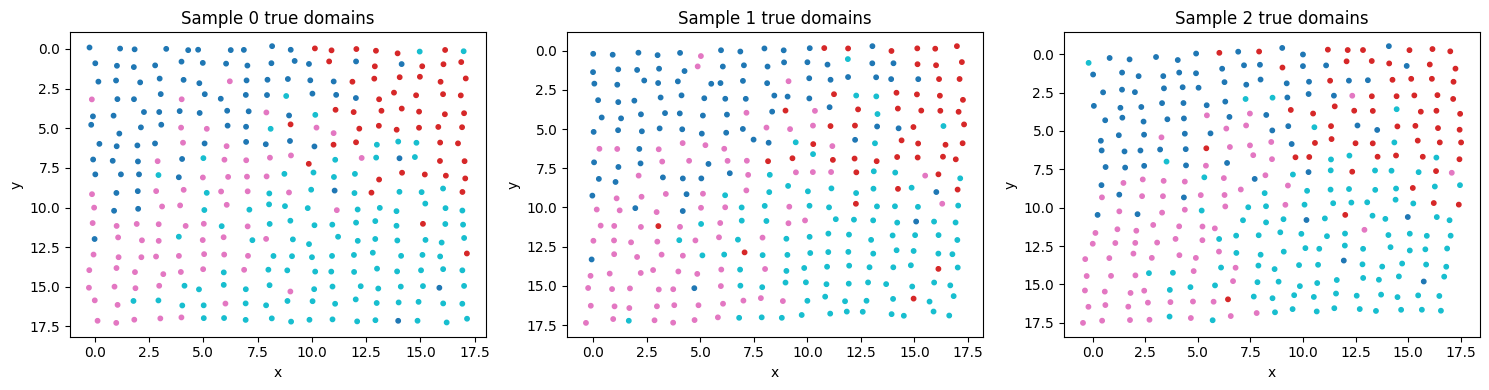

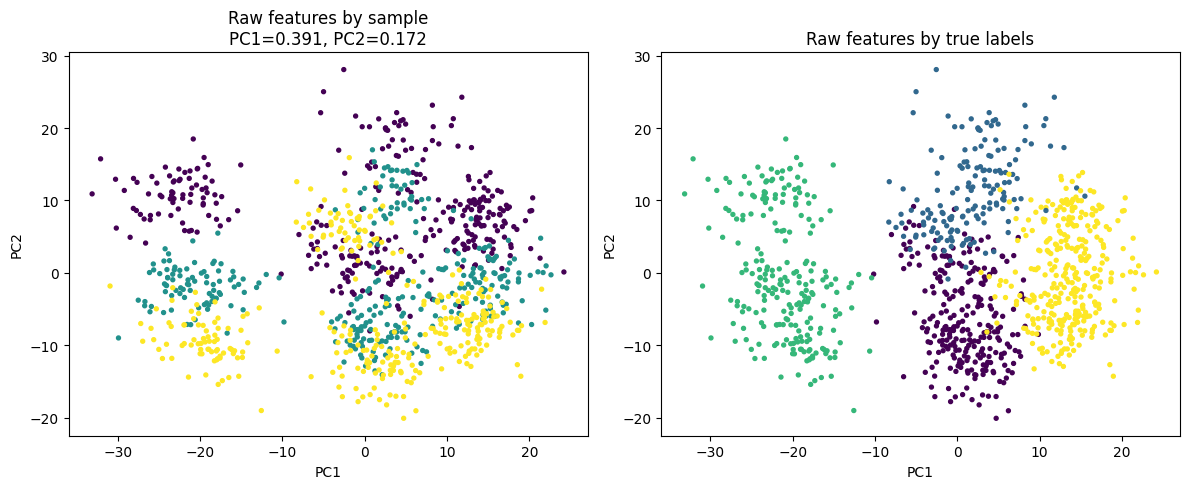

In [5]:

fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(5 * NUM_SAMPLES, 4))
start = 0
for sid in range(NUM_SAMPLES):
    n = len(coords_list[sid])
    axes[sid].scatter(coords_list[sid][:, 0], coords_list[sid][:, 1], c=true_labels[start:start+n], s=10, cmap="tab10")
    axes[sid].set_title(f"Sample {sid} true domains")
    axes[sid].set_xlabel("x")
    axes[sid].set_ylabel("y")
    axes[sid].invert_yaxis()
    start += n
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "true_domains.png"), dpi=250, bbox_inches="tight")
plt.show()

raw_concat = np.concatenate([X_rna_all, X_prot_all], axis=1)
raw2, raw_exp = pca_2d(raw_concat)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(raw2[:, 0], raw2[:, 1], c=sample_ids, s=8)
axes[0].set_title(f"Raw features by sample\nPC1={raw_exp[0]:.3f}, PC2={raw_exp[1]:.3f}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(raw2[:, 0], raw2[:, 1], c=true_labels, s=8)
axes[1].set_title("Raw features by true labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "raw_feature_pca.png"), dpi=250, bbox_inches="tight")
plt.show()


## 6. Build disconnected spatial and feature graphs

In [6]:

spatial_edge_index = build_disconnected_graph(coords_list, k=SPATIAL_K)
rna_feature_edge_index = build_disconnected_graph(X_rna_list, k=FEATURE_K)
prot_feature_edge_index = build_disconnected_graph(X_prot_list, k=FEATURE_K)

X_rna_t = torch.tensor(X_rna_all, dtype=torch.float32)
X_prot_t = torch.tensor(X_prot_all, dtype=torch.float32)
sample_ids_t = torch.tensor(sample_ids, dtype=torch.long)

print("Spatial graph:", tuple(spatial_edge_index.shape))
print("RNA feature graph:", tuple(rna_feature_edge_index.shape))
print("Protein feature graph:", tuple(prot_feature_edge_index.shape))


Spatial graph: (2, 11664)
RNA feature graph: (2, 19440)
Protein feature graph: (2, 19440)


## 7. Train the same model without and with MMD batch correction

In [7]:

model_no_batch = SpatialGlueMini(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_modalities=2,
    dropout=0.1,
)

model_no_batch, history_no_batch = train_with_history(
    model_no_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=None,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=0.0,
    device=DEVICE,
)

Z_no_batch, _ = get_latent(
    model_no_batch,
    [X_rna_t, X_prot_t],
    spatial_edge_index,
    [rna_feature_edge_index, prot_feature_edge_index],
)

model_mmd = SpatialGlueMini(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_modalities=2,
    dropout=0.1,
)

model_mmd, history_mmd = train_with_history(
    model_mmd,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=sample_ids_t,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=LAMBDA_BATCH,
    device=DEVICE,
)

Z_mmd, _ = get_latent(
    model_mmd,
    [X_rna_t, X_prot_t],
    spatial_edge_index,
    [rna_feature_edge_index, prot_feature_edge_index],
)


Epoch 0001 | total=26.3869 | recon=20.1700 | corr=6.2169 | batch=0.0000 | lambda_batch=0.000
Epoch 0100 | total=5.5443 | recon=5.0713 | corr=0.4731 | batch=0.0000 | lambda_batch=0.000
Epoch 0200 | total=3.4805 | recon=3.2252 | corr=0.2553 | batch=0.0000 | lambda_batch=0.000
Epoch 0300 | total=2.7705 | recon=2.5417 | corr=0.2288 | batch=0.0000 | lambda_batch=0.000
Epoch 0400 | total=2.2180 | recon=2.0090 | corr=0.2090 | batch=0.0000 | lambda_batch=0.000
Epoch 0001 | total=27.0216 | recon=20.6296 | corr=6.3905 | batch=0.1815 | lambda_batch=0.008
Epoch 0100 | total=5.7158 | recon=5.0663 | corr=0.4713 | batch=0.2139 | lambda_batch=0.833
Epoch 0200 | total=3.5904 | recon=3.1892 | corr=0.2618 | batch=0.1394 | lambda_batch=1.000
Epoch 0300 | total=2.8755 | recon=2.4907 | corr=0.2741 | batch=0.1107 | lambda_batch=1.000
Epoch 0400 | total=2.3040 | recon=1.9789 | corr=0.2272 | batch=0.0979 | lambda_batch=1.000


## 8. Training curves

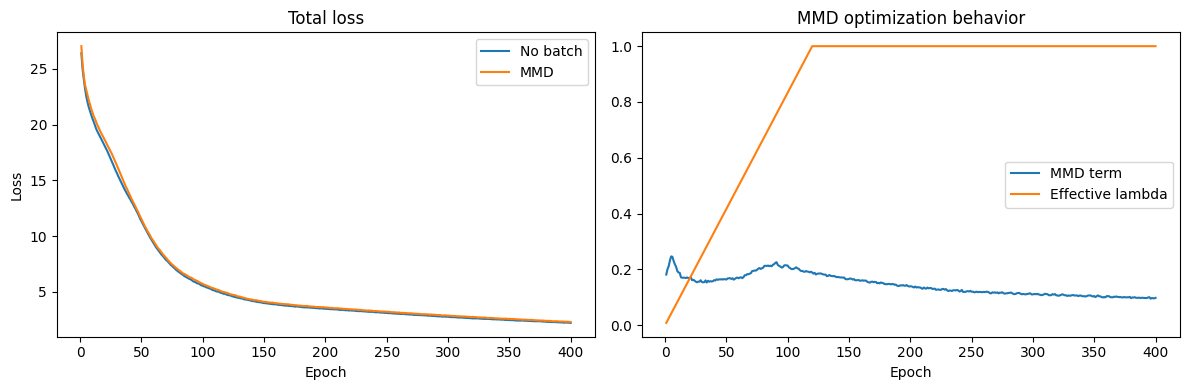

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_no_batch["epoch"], history_no_batch["total"], label="No batch")
axes[0].plot(history_mmd["epoch"], history_mmd["total"], label="MMD")
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_mmd["epoch"], history_mmd["batch"], label="MMD term")
axes[1].plot(history_mmd["epoch"], history_mmd["effective_lambda_batch"], label="Effective lambda")
axes[1].set_title("MMD optimization behavior")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_curves.png"), dpi=250, bbox_inches="tight")
plt.show()


## 9. Evaluate raw features, no-batch latent space, and MMD latent space (including ARI and NMI)

In [9]:

metrics_raw, labels_raw, centers_raw = evaluate_representation(
    "Raw observed features", raw_concat, sample_ids, true_labels, coords_list
)
metrics_no_batch, labels_no_batch, centers_no_batch = evaluate_representation(
    "No batch correction", Z_no_batch, sample_ids, true_labels, coords_list
)
metrics_mmd, labels_mmd, centers_mmd = evaluate_representation(
    "MMD batch correction", Z_mmd, sample_ids, true_labels, coords_list
)

results_df = pd.DataFrame([metrics_raw, metrics_no_batch, metrics_mmd])
display(results_df.round(4))
results_df.to_csv(os.path.join(TAB_DIR, "simulation_metrics.csv"), index=False)


,method,batch_silhouette,batch_entropy,ARI_vs_truth,NMI_vs_truth,sample_centroid_distance,sample_cluster_jsd,spatial_coherence
0,Raw observed features,0.1612,0.0047,0.9778,0.9641,17.1880,0.0016,0.6391
1,No batch correction,0.2915,0.0000,0.3145,0.4024,6.6651,0.5274,0.8002
2,MMD batch correction,0.1355,0.0016,0.9828,0.9724,3.8771,0.0016,0.6468


In [10]:

ari_nmi_summary = results_df[["method", "ARI_vs_truth", "NMI_vs_truth"]].copy()
display(ari_nmi_summary.round(4))
ari_nmi_summary.to_csv(os.path.join(TAB_DIR, "ari_nmi_summary.csv"), index=False)


,method,ARI_vs_truth,NMI_vs_truth
0,Raw observed features,0.9778,0.9641
1,No batch correction,0.3145,0.4024
2,MMD batch correction,0.9828,0.9724


## 10. Centroid validation

In [11]:

centroid_overview_df = pd.concat([
    sample_centroid_table(raw_concat, sample_ids).assign(method="Raw observed features"),
    sample_centroid_table(Z_no_batch, sample_ids).assign(method="No batch correction"),
    sample_centroid_table(Z_mmd, sample_ids).assign(method="MMD batch correction"),
], ignore_index=True)

pairwise_centroid_df = pd.concat([
    pairwise_sample_centroid_distances(raw_concat, sample_ids).assign(method="Raw observed features"),
    pairwise_sample_centroid_distances(Z_no_batch, sample_ids).assign(method="No batch correction"),
    pairwise_sample_centroid_distances(Z_mmd, sample_ids).assign(method="MMD batch correction"),
], ignore_index=True)

display(centroid_overview_df.round(4))
display(pairwise_centroid_df.round(4))

centroid_overview_df.to_csv(os.path.join(TAB_DIR, "sample_centroids.csv"), index=False)
pairwise_centroid_df.to_csv(os.path.join(TAB_DIR, "pairwise_centroid_distances.csv"), index=False)


,sample_id,centroid_norm,centroid_dim1,centroid_dim2,centroid_dim3,centroid_dim4,centroid_dim5,method
0,0,17.5805,-6.1748,0.8776,-2.1287,2.0521,1.8252,Raw observed features
1,1,13.3749,-3.0032,1.3558,1.2518,0.8163,-0.6734,Raw observed features
2,2,15.3711,-4.0070,0.8754,-1.2809,-0.0999,-1.6795,Raw observed features
3,0,8.4533,0.9669,-1.0376,2.1988,0.6838,0.2953,No batch correction
4,1,7.3731,0.0592,-2.3704,2.6187,1.8102,1.2954,No batch correction
5,2,7.9010,3.2455,-2.0254,0.8068,0.2904,-0.9355,No batch correction
6,0,7.2702,-2.8949,2.9595,-1.6339,-0.4989,-0.4822,MMD batch correction
7,1,6.7691,-3.9848,2.1370,-2.0004,0.0508,-0.2516,MMD batch correction
8,2,6.8426,-2.7243,1.4381,-1.5034,-1.5920,-1.6803,MMD batch correction


,sample_i,sample_j,centroid_distance,method
0,0,1,17.1083,Raw observed features
1,0,2,18.7291,Raw observed features
2,1,2,15.7265,Raw observed features
3,0,1,6.2343,No batch correction
4,0,2,7.6899,No batch correction
5,1,2,6.0712,No batch correction
6,0,1,3.9743,MMD batch correction
7,0,2,3.9426,MMD batch correction
8,1,2,3.7143,MMD batch correction


## 11. PCA comparison plots

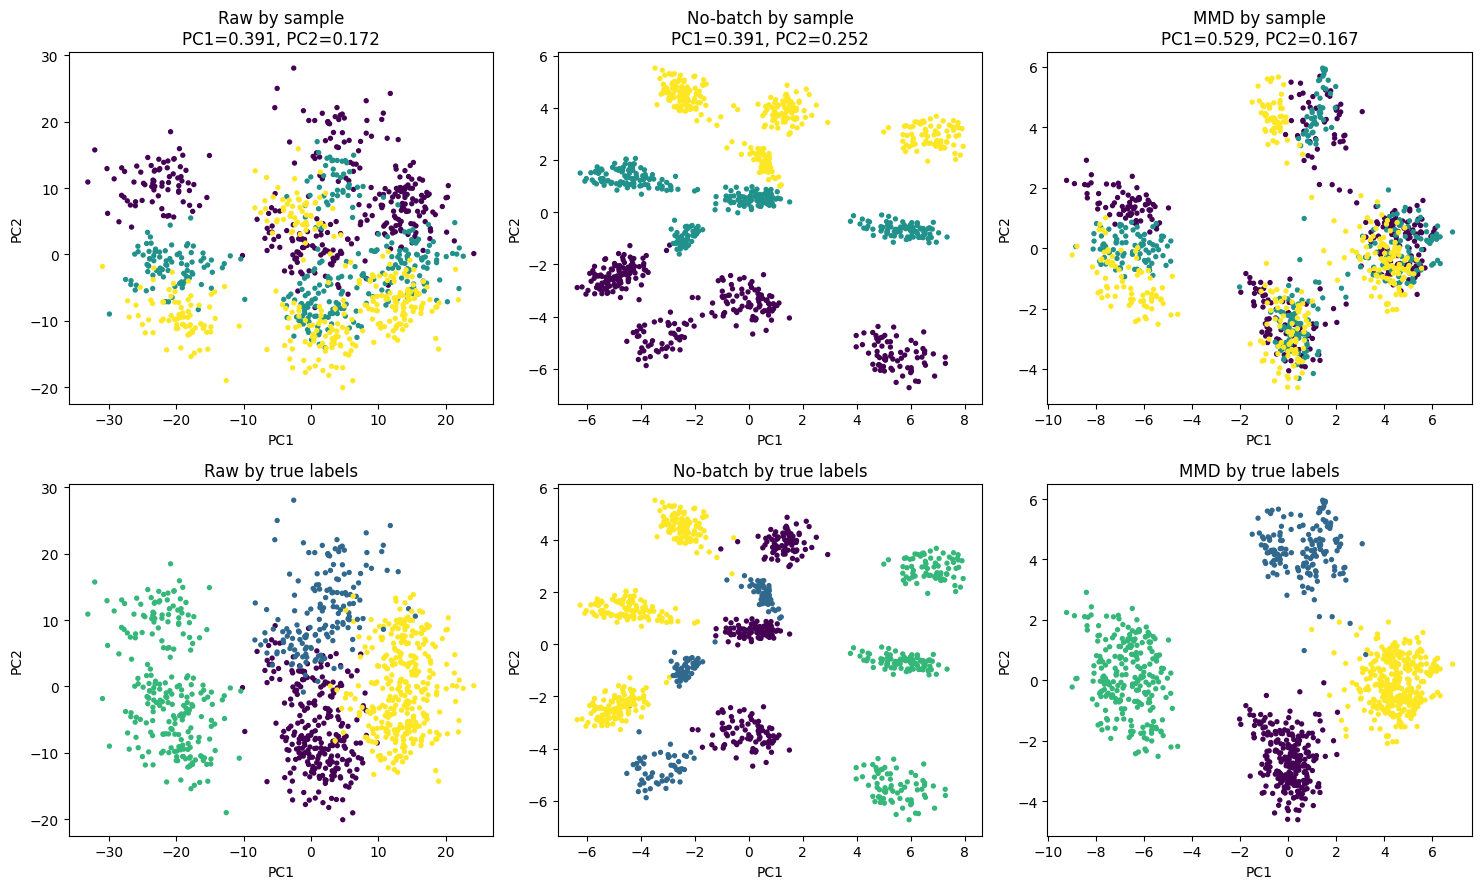

In [12]:

Z2_raw, exp_raw = pca_2d(raw_concat)
Z2_no, exp_no = pca_2d(Z_no_batch)
Z2_mmd, exp_mmd = pca_2d(Z_mmd)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].scatter(Z2_raw[:, 0], Z2_raw[:, 1], c=sample_ids, s=8)
axes[0, 0].set_title(f"Raw by sample\nPC1={exp_raw[0]:.3f}, PC2={exp_raw[1]:.3f}")
axes[0, 1].scatter(Z2_no[:, 0], Z2_no[:, 1], c=sample_ids, s=8)
axes[0, 1].set_title(f"No-batch by sample\nPC1={exp_no[0]:.3f}, PC2={exp_no[1]:.3f}")
axes[0, 2].scatter(Z2_mmd[:, 0], Z2_mmd[:, 1], c=sample_ids, s=8)
axes[0, 2].set_title(f"MMD by sample\nPC1={exp_mmd[0]:.3f}, PC2={exp_mmd[1]:.3f}")

axes[1, 0].scatter(Z2_raw[:, 0], Z2_raw[:, 1], c=true_labels, s=8)
axes[1, 0].set_title("Raw by true labels")
axes[1, 1].scatter(Z2_no[:, 0], Z2_no[:, 1], c=true_labels, s=8)
axes[1, 1].set_title("No-batch by true labels")
axes[1, 2].scatter(Z2_mmd[:, 0], Z2_mmd[:, 1], c=true_labels, s=8)
axes[1, 2].set_title("MMD by true labels")

for ax in axes.ravel():
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "pca_comparison.png"), dpi=250, bbox_inches="tight")
plt.show()



## 13. Simulation workflow summary

1. Create shared latent biological prototypes for the simulated tissue domains.
2. Generate one spatial layout for each synthetic sample on a perturbed grid.
3. Assign known ground-truth domain labels using smooth nonlinear spatial boundaries.
4. Generate latent biological states around those domain prototypes.
5. Project the latent biology into RNA-like and protein-like observed feature spaces.
6. Inject batch effects using shifts, scales, latent warps, and spatially varying corruption.
7. Build disconnected spatial and feature graphs for each sample.
8. Train the same SpatialGLUE-style model:
   - once without batch correction
   - once with MMD batch correction
9. Cluster each representation and compute:
   - batch silhouette
   - batch entropy
   - **ARI**
   - **NMI**
   - centroid-based validation
   - spatial coherence
10. Compare the outputs with tables and PCA plots to determine whether MMD improves batch mixing without destroying the known biological structure.



## 12. Results summary and interpretation

The block below automatically summarizes the key findings from the simulation using the metrics already computed in `results_df`.

It compares:
- **Raw observed features**
- **No batch correction**
- **MMD batch correction**

and interprets whether MMD:
- improved batch mixing,
- preserved the known simulated biology,
- reduced sample-level separation in the latent space,
- or overcorrected.


In [13]:

from IPython.display import Markdown, display

def _get_row(df, method_name):
    row = df[df["method"] == method_name]
    if len(row) == 0:
        raise ValueError(f"Method '{method_name}' not found in results_df")
    return row.iloc[0]

raw_row = _get_row(results_df, "Raw observed features")
no_row = _get_row(results_df, "No batch correction")
mmd_row = _get_row(results_df, "MMD batch correction")

def fmt(x):
    return f"{x:.4f}"

delta_sil = mmd_row["batch_silhouette"] - no_row["batch_silhouette"]
delta_ent = mmd_row["batch_entropy"] - no_row["batch_entropy"]
delta_ari = mmd_row["ARI_vs_truth"] - no_row["ARI_vs_truth"]
delta_nmi = mmd_row["NMI_vs_truth"] - no_row["NMI_vs_truth"]
delta_cent = mmd_row["sample_centroid_distance"] - no_row["sample_centroid_distance"]
delta_jsd = mmd_row["sample_cluster_jsd"] - no_row["sample_cluster_jsd"]
delta_spatial = mmd_row["spatial_coherence"] - no_row["spatial_coherence"]

batch_improved = (delta_sil < 0) and (delta_ent > 0)
biology_preserved = (delta_ari > -0.05) and (delta_nmi > -0.05)
centroids_improved = (delta_cent < 0)
composition_improved = (delta_jsd < 0)
spatial_preserved = (delta_spatial > -0.05)

if batch_improved and biology_preserved:
    verdict = "Overall, **MMD appears to be helping**: batch mixing improved while biological structure was largely preserved."
elif batch_improved and not biology_preserved:
    verdict = "Overall, **MMD improves batch mixing but may be overcorrecting** because biological structure dropped noticeably."
elif (not batch_improved) and biology_preserved:
    verdict = "Overall, **MMD preserved biology but did not clearly improve batch correction** in this run."
else:
    verdict = "Overall, **this run does not show convincing evidence that MMD helped**. Both batch and biological metrics should be inspected closely."

summary_md = f'''
### Metric table recap

| Method | Batch silhouette ↓ | Batch entropy ↑ | ARI ↑ | NMI ↑ | Centroid distance ↓ | Cluster JSD ↓ | Spatial coherence ↑ |
|---|---:|---:|---:|---:|---:|---:|---:|
| Raw observed features | {fmt(raw_row["batch_silhouette"])} | {fmt(raw_row["batch_entropy"])} | {fmt(raw_row["ARI_vs_truth"])} | {fmt(raw_row["NMI_vs_truth"])} | {fmt(raw_row["sample_centroid_distance"])} | {fmt(raw_row["sample_cluster_jsd"])} | {fmt(raw_row["spatial_coherence"])} |
| No batch correction | {fmt(no_row["batch_silhouette"])} | {fmt(no_row["batch_entropy"])} | {fmt(no_row["ARI_vs_truth"])} | {fmt(no_row["NMI_vs_truth"])} | {fmt(no_row["sample_centroid_distance"])} | {fmt(no_row["sample_cluster_jsd"])} | {fmt(no_row["spatial_coherence"])} |
| MMD batch correction | {fmt(mmd_row["batch_silhouette"])} | {fmt(mmd_row["batch_entropy"])} | {fmt(mmd_row["ARI_vs_truth"])} | {fmt(mmd_row["NMI_vs_truth"])} | {fmt(mmd_row["sample_centroid_distance"])} | {fmt(mmd_row["sample_cluster_jsd"])} | {fmt(mmd_row["spatial_coherence"])} |

### Direct comparison: MMD vs. no-batch model

- Batch silhouette change: **{fmt(delta_sil)}**
- Batch entropy change: **{fmt(delta_ent)}**
- ARI change: **{fmt(delta_ari)}**
- NMI change: **{fmt(delta_nmi)}**
- Centroid distance change: **{fmt(delta_cent)}**
- Sample cluster JSD change: **{fmt(delta_jsd)}**
- Spatial coherence change: **{fmt(delta_spatial)}**

### Interpretation

{verdict}

#### How to read this run
- **Lower batch silhouette** and **higher batch entropy** indicate better batch mixing.
- **Higher ARI/NMI** indicate better recovery of the known simulated ground-truth domains.
- **Lower centroid distance** means sample means are closer in the representation, suggesting reduced sample-specific separation.
- **Lower sample cluster JSD** means cluster composition is becoming more consistent across samples.
- **Stable spatial coherence** means the method did not destroy local spatial organization while correcting batch effects.

#### What to conclude from this notebook
This simulation is a **single annotated stress test** of whether the MMD term helps. Because the data is synthetic and annotated by construction, ARI and NMI are meaningful here. The most important question is whether MMD improves batch metrics **without** causing a substantial drop in ARI, NMI, or spatial coherence.
'''
display(Markdown(summary_md))



### Metric table recap

| Method | Batch silhouette ↓ | Batch entropy ↑ | ARI ↑ | NMI ↑ | Centroid distance ↓ | Cluster JSD ↓ | Spatial coherence ↑ |
|---|---:|---:|---:|---:|---:|---:|---:|
| Raw observed features | 0.1612 | 0.0047 | 0.9778 | 0.9641 | 17.1880 | 0.0016 | 0.6391 |
| No batch correction | 0.2915 | 0.0000 | 0.3145 | 0.4024 | 6.6651 | 0.5274 | 0.8002 |
| MMD batch correction | 0.1355 | 0.0016 | 0.9828 | 0.9724 | 3.8771 | 0.0016 | 0.6468 |

### Direct comparison: MMD vs. no-batch model

- Batch silhouette change: **-0.1560**
- Batch entropy change: **0.0016**
- ARI change: **0.6683**
- NMI change: **0.5699**
- Centroid distance change: **-2.7881**
- Sample cluster JSD change: **-0.5259**
- Spatial coherence change: **-0.1535**

### Interpretation

Overall, **MMD appears to be helping**: batch mixing improved while biological structure was largely preserved.

#### How to read this run
- **Lower batch silhouette** and **higher batch entropy** indicate better batch mixing.
- **Higher ARI/NMI** indicate better recovery of the known simulated ground-truth domains.
- **Lower centroid distance** means sample means are closer in the representation, suggesting reduced sample-specific separation.
- **Lower sample cluster JSD** means cluster composition is becoming more consistent across samples.
- **Stable spatial coherence** means the method did not destroy local spatial organization while correcting batch effects.

#### What to conclude from this notebook
This simulation is a **single annotated stress test** of whether the MMD term helps. Because the data is synthetic and annotated by construction, ARI and NMI are meaningful here. The most important question is whether MMD improves batch metrics **without** causing a substantial drop in ARI, NMI, or spatial coherence.
